# Capstone — Structured Content Archetype Clustering

**Author:** Farhan
**Lane:** Structured Content Archetype Clustering
**Repo:** https://github.com/muhammadfarhan2157-source/flyrank-ml-internship
**Data:** `data/raw/content_refresh_anonymized.csv` (30,000 pages, 32 pseudonymized clients, 90-day trailing window)

**Question:** What performance archetypes exist across the content inventory, and what action does each archetype call for?

This notebook is the reproducible source for the deployed paper (`docs/capstone.html`). Run top to bottom on a fresh clone; the only input is the anonymized starter CSV already committed under `data/raw/`.

## 0. Data contract

- **Unit of analysis:** one row = one content page, aggregated over a trailing 90-day window.
- **Time window:** all `*_90d` totals share the same 90-day window; `*_last_30d` / `*_prev_30d` are the two 30-day sub-windows used only to derive `trend_pct` / `trend_direction`.
- **Feature fields (this notebook):** current-state performance and content-property metrics — impressions/clicks/sessions/AI-sessions (log-scaled), CTR, engagement rate, scroll rate, AI-traffic %, average position, word count, search volume, content age, days since last update.
- **Excluded from clustering:**
  - `trend_direction` / `trend_pct` — these are the *label* columns per the data dictionary; they're used only afterward, to describe each cluster's decline mix, never as clustering inputs.
  - `content_id` / `client_id` — pseudonymous identifiers, used only for grouping/joins, never as features.
  - `provider_used` / `model_used` — excluded per the data dictionary ("not a model feature").
  - No raw URLs, client names, or keyword text are present in this slice, and none are used.
- **Missingness is patterned, not random** (verified below): `word_count`/`char_count` are missing for `keyword article` rows specifically, and `search_volume`/`competition`/`cpc` are missing whenever a page has no keyword-context data (100% of `feedly article` rows). A blind `fillna(0)` would silently encode `content_type` into the clustering, so missing numeric fields get an explicit `had_<field>` indicator column instead of being zero-filled.
- **Output:** cluster assignments, a plain-language archetype name and one-line profile per cluster, and an action mapping (protect / improve / rewrite / monitor / merge / prune) editors can act on.

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.width', 140)
df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')
print(df.shape)
print("Distinct clients:", df['client_id'].nunique())

(30000, 44)
Distinct clients: 32


In [2]:
# Verify the missingness pattern claimed in the data contract (per data-dictionary.md)
print("search_volume missing % by content_type:")
print(df.groupby('content_type')['search_volume'].apply(lambda s: round(s.isna().mean()*100,1)))
print()
print("word_count missing % by content_type:")
print(df.groupby('content_type')['word_count'].apply(lambda s: round(s.isna().mean()*100,1)))
print()
print("trend_direction counts (used later for cluster description, never as a feature):")
print(df['trend_direction'].value_counts())

search_volume missing % by content_type:
content_type
comparison article      0.0
feedly article        100.0
keyword article         1.4
Name: search_volume, dtype: float64

word_count missing % by content_type:
content_type
comparison article     0.0
feedly article         0.0
keyword article       28.3
Name: word_count, dtype: float64

trend_direction counts (used later for cluster description, never as a feature):
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64


## 1. Feature engineering

Numeric traffic totals are heavy-tailed, so they're log-transformed (`log1p`). `avg_position == 0` means *no position data*, not "position zero" (per the data dictionary), so it's replaced with `NaN` and carried alongside an explicit `has_position_data` flag rather than silently treated as a great ranking. The same explicit-flag treatment is used for `word_count` and `search_volume`, since their absence tracks `content_type`, not randomness.

In [3]:
df['avg_position_clean'] = df['avg_position'].replace(0, np.nan)
df['has_position_data'] = (df['avg_position'] > 0).astype(int)

for base in ['impressions_90d','clicks_90d','sessions_90d','ai_sessions_90d','word_count','search_volume']:
    df[f'log_{base}'] = np.log1p(df[base])

df['days_since_update_capped'] = df['days_since_last_update'].clip(upper=df['days_since_last_update'].quantile(0.99))
df['had_word_count'] = df['word_count'].notna().astype(int)
df['had_search_volume'] = df['search_volume'].notna().astype(int)

feature_cols = [
    'log_impressions_90d', 'log_clicks_90d', 'log_sessions_90d', 'log_ai_sessions_90d',
    'ctr', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct',
    'avg_position_clean', 'has_position_data',
    'log_word_count', 'had_word_count',
    'log_search_volume', 'had_search_volume',
    'content_age_days', 'days_since_update_capped',
]

X = df[feature_cols].copy()
# Genuinely-missing numeric metrics: median-impute, but the had_/has_ flags above keep
# "no data" visible to the clustering rather than pretending it's an average page.
for c in ['avg_position_clean', 'log_word_count', 'log_search_volume']:
    X[c] = X[c].fillna(X[c].median())
for c in ['engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'ctr']:
    X[c] = X[c].fillna(0)

X.isna().sum().sum()  # sanity check: 0 remaining nulls before scaling

np.int64(0)

## 2. Scaling, choosing k, and fitting KMeans

Features are standardized (zero mean, unit variance) so that raw-count columns like impressions don't dominate rate columns like CTR. `k` is chosen by silhouette score across a small candidate grid — the grid and the winning score are shown, not just the final `k`, so the choice is checkable.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

scores = {}
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xs)
    idx = np.random.choice(len(Xs), size=6000, replace=False)  # subsample: silhouette is O(n^2)
    scores[k] = silhouette_score(Xs[idx], labels[idx])

for k, s in scores.items():
    print(f"k={k}  silhouette={s:.4f}")

best_k = max(scores, key=scores.get)
print("\nChosen k:", best_k)

k=3  silhouette=0.1605
k=4  silhouette=0.1774
k=5  silhouette=0.1772
k=6  silhouette=0.1985
k=7  silhouette=0.1964
k=8  silhouette=0.1946

Chosen k: 6


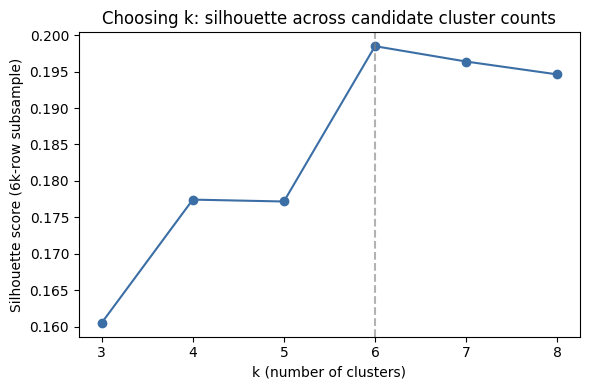

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(list(scores.keys()), list(scores.values()), marker='o', color='#3b6ea5')
plt.axvline(best_k, color='gray', linestyle='--', alpha=0.6)
plt.xlabel('k (number of clusters)')
plt.ylabel('Silhouette score (6k-row subsample)')
plt.title('Choosing k: silhouette across candidate cluster counts')
plt.tight_layout()
plt.savefig('figures/k_selection.png', dpi=130)
plt.show()

In [6]:
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(Xs)
df['cluster'].value_counts().sort_index()

cluster
0     1601
1     6773
2     7866
3    11295
4     1195
5     1270
Name: count, dtype: int64

## 3. Cluster stability check (before trusting the clusters)

Per the lane's own warning ("treating clusters as true labels instead of a lens" / "do the clusters survive a re-run?"), stability is checked two ways: re-fitting with different random seeds, and re-fitting on bootstrap resamples — both compared to the original assignment with Adjusted Rand Index (1.0 = identical, 0.0 = random agreement).

In [7]:
from sklearn.metrics import adjusted_rand_score

base_labels = df['cluster'].values
seed_aris = []
for seed in [1, 2, 3, 7, 99]:
    labels = KMeans(n_clusters=best_k, random_state=seed, n_init=10).fit_predict(Xs)
    seed_aris.append(adjusted_rand_score(base_labels, labels))
print("ARI vs. seed 42, across 5 other seeds:", [round(a,3) for a in seed_aris])

rng = np.random.default_rng(0)
boot_aris = []
for i in range(5):
    idx = rng.choice(len(Xs), size=len(Xs), replace=True)
    labels_boot = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(Xs[idx])
    boot_aris.append(adjusted_rand_score(base_labels[idx], labels_boot))
print("ARI on bootstrap resamples:", [round(a,3) for a in boot_aris])

ARI vs. seed 42, across 5 other seeds: [0.853, 0.997, 0.845, 0.994, 0.997]


ARI on bootstrap resamples: [0.851, 0.99, 0.988, 0.851, 0.798]


**Reading this honestly:** silhouette scores in the 0.16–0.20 range mean the six groups overlap considerably in feature space — this is a spectrum of content performance, not six sharply separated species of page. But ARI values mostly in the 0.80–1.00 range across both re-seeding and bootstrap resampling mean the *grouping itself* is reproducible: the same six regions of the data keep showing up, even though their edges are fuzzy. Both things are true at once, and the paper says so.

## 4. PCA projection (for visualization only)

PCA is used purely to plot the 16-dimensional feature space in 2D — it is not the clustering method itself (KMeans runs on the full standardized feature set above).

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(Xs)
df['pca1'], df['pca2'] = coords[:, 0], coords[:, 1]
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3),
      "  sum =", round(pca.explained_variance_ratio_.sum(), 3))

Explained variance ratio: [0.21  0.125]   sum = 0.335


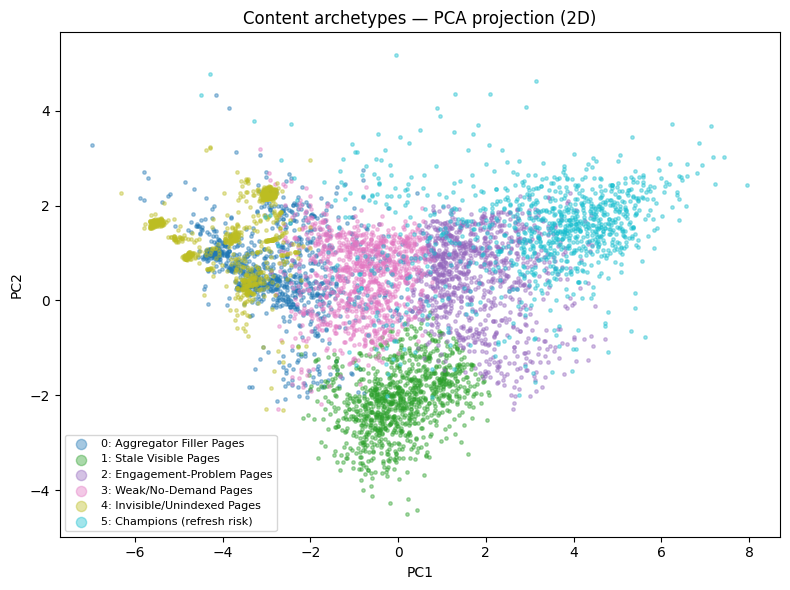

In [9]:
import matplotlib.pyplot as plt

archetype_map = {
    5: 'Champions (refresh risk)',
    2: 'Engagement-Problem Pages',
    1: 'Stale Visible Pages',
    3: 'Weak/No-Demand Pages',
    0: 'Aggregator Filler Pages',
    4: 'Invisible/Unindexed Pages',
}
df['archetype'] = df['cluster'].map(archetype_map)

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 6))
for c in sorted(df['cluster'].unique()):
    sub = df[df['cluster'] == c].sample(min(1000, (df['cluster'] == c).sum()), random_state=1)
    ax.scatter(sub['pca1'], sub['pca2'], s=6, alpha=0.4, color=colors[c], label=f"{c}: {archetype_map[c]}")
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Content archetypes — PCA projection (2D)')
ax.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.savefig('figures/pca_clusters.png', dpi=130)
plt.show()

## 5. Cluster profiling — describing each cluster before naming it

Per the lane's warning against "naming clusters before actually inspecting what is in them," every cluster is profiled on its median raw metrics (impressions, clicks, CTR, position, engagement, word count, search volume, age, freshness) and its `content_type` mix and decline/growth rate — computed but never used as an input to the clustering — *before* any archetype label is assigned.

In [10]:
profile_cols = ['impressions_90d', 'clicks_90d', 'sessions_90d', 'ai_sessions_90d', 'ctr',
                'avg_position_clean', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct',
                'word_count', 'search_volume', 'content_age_days', 'days_since_last_update']

profile = df.groupby('cluster')[profile_cols].median().round(2)
profile['n_pages'] = df['cluster'].value_counts().sort_index()
profile['pct_declining'] = df.groupby('cluster')['trend_direction'].apply(lambda s: round((s == 'down').mean()*100, 1))
profile['pct_up'] = df.groupby('cluster')['trend_direction'].apply(lambda s: round((s == 'up').mean()*100, 1))
profile['dominant_content_type'] = df.groupby('cluster')['content_type'].agg(lambda s: s.value_counts().idxmax())
profile['archetype'] = profile.index.map(archetype_map)
profile.reset_index().to_json('../outputs/cluster_profile.json', orient='records', indent=2)
profile

,impressions_90d,clicks_90d,sessions_90d,ai_sessions_90d,ctr,avg_position_clean,engagement_rate,scroll_rate,ai_traffic_pct,word_count,search_volume,content_age_days,days_since_last_update,n_pages,pct_declining,pct_up,dominant_content_type,archetype
cluster,,,,,,,,,,,,,,,,,,
0,17.0,0.0,2.0,0.0,0.00,6.6,0.00,25.00,0.00,1132.0,0.0,301.0,20.0,1601,41.9,17.0,feedly article,Aggregator Filler Pages
1,693.0,0.0,6.0,0.0,0.00,15.5,0.00,0.00,0.00,2853.0,20.0,441.0,22.0,6773,46.5,23.0,keyword article,Stale Visible Pages
2,6549.5,16.0,45.0,0.0,0.25,8.9,1.73,5.71,0.00,3110.0,0.0,223.0,25.0,7866,59.2,12.7,keyword article,Engagement-Problem Pages
3,201.0,0.0,3.0,0.0,0.00,12.0,0.00,12.50,0.00,2787.0,10.0,147.0,20.0,11295,62.8,12.4,keyword article,Weak/No-Demand Pages
4,1.0,0.0,3.0,0.0,0.00,NaN,0.00,20.83,0.00,1636.5,10.0,282.0,20.0,1195,0.6,0.0,feedly article,Invisible/Unindexed Pages
5,9578.5,23.5,117.5,3.0,0.23,18.0,1.96,5.08,3.15,5152.5,0.0,229.0,104.0,1270,54.1,12.7,keyword article,Champions (refresh risk)


## 6. Archetype names and action mapping

Reading the profile table above (not before it):

| Cluster | Archetype | Read from the profile | Action |
|---|---|---|---|
| 5 | **Champions (refresh risk)** | Highest impressions & sessions, longest content, only cluster with meaningful AI-referral sessions — but the highest `days_since_last_update` (~104d vs ~20–25d elsewhere) | Protect + monitor freshness |
| 2 | **Engagement-Problem Pages** | High impressions, decent position (~p.1), but very low CTR (0.25%) and engagement (1.7%) relative to that volume | Improve (metadata/CTR + on-page engagement) |
| 1 | **Stale Visible Pages** | Oldest median content age (~441d), moderate impressions, page-2 position, essentially zero measured clicks/engagement | Rewrite / refresh |
| 3 | **Weak/No-Demand Pages** | Largest cluster (37.7% of pages), youngest median age, low impressions, near-zero engagement, low search volume | Monitor (prune the weakest tail) |
| 0 | **Aggregator Filler Pages** | Dominated by `feedly article`, zero search volume (no keyword target), negligible impressions/clicks despite a decent average position | Merge or prune |
| 4 | **Invisible/Unindexed Pages** | Near-zero impressions, mostly no position data at all, and — tellingly — almost no decline *or* growth (they're already at the floor) | Investigate indexing / prune |

No cluster here maps cleanly to "cannibalization-risk" or true semantic "hidden gems" — this dataset has no article text and no shared-keyword mapping across pages, so neither claim is supportable from what's in the data (see `data-dictionary.md`: no article text ⇒ no semantic clustering; keyword identity isn't joined across rows in this starter slice).

In [11]:
action_map = {
    5: 'Protect + monitor freshness',
    2: 'Improve (metadata/CTR + on-page engagement)',
    1: 'Rewrite / refresh',
    3: 'Monitor (prune weakest tail)',
    0: 'Merge or prune',
    4: 'Investigate indexing / prune',
}
df['action'] = df['cluster'].map(action_map)

action_queue = (df.groupby(['cluster', 'archetype', 'action'])
                  .agg(n_pages=('content_id', 'count'),
                       median_impressions_90d=('impressions_90d', 'median'),
                       median_ctr=('ctr', 'median'),
                       pct_declining=('trend_direction', lambda s: round((s == 'down').mean()*100, 1)))
                  .reset_index()
                  .sort_values('n_pages', ascending=False))
action_queue.to_json('../outputs/action_mapping.json', orient='records', indent=2)
action_queue

,cluster,archetype,action,n_pages,median_impressions_90d,median_ctr,pct_declining
3,3,Weak/No-Demand Pages,Monitor (prune weakest tail),11295,201.0,0.00,62.8
2,2,Engagement-Problem Pages,Improve (metadata/CTR + on-page engagement),7866,6549.5,0.25,59.2
1,1,Stale Visible Pages,Rewrite / refresh,6773,693.0,0.00,46.5
0,0,Aggregator Filler Pages,Merge or prune,1601,17.0,0.00,41.9
5,5,Champions (refresh risk),Protect + monitor freshness,1270,9578.5,0.23,54.1
4,4,Invisible/Unindexed Pages,Investigate indexing / prune,1195,1.0,0.00,0.6


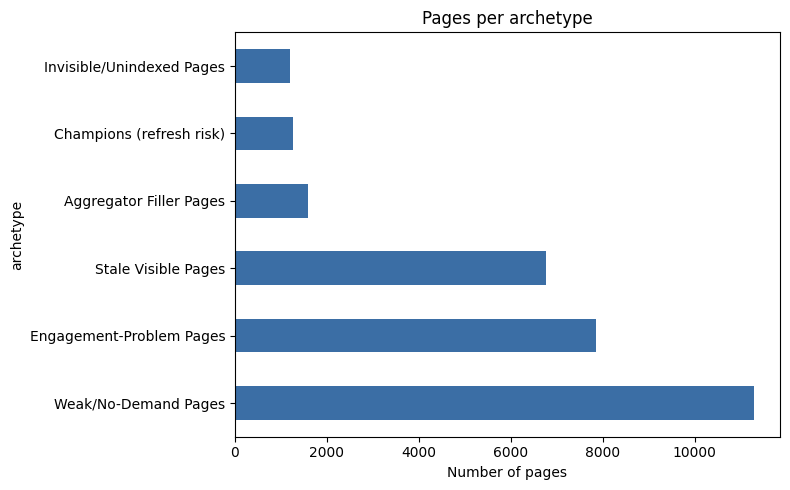

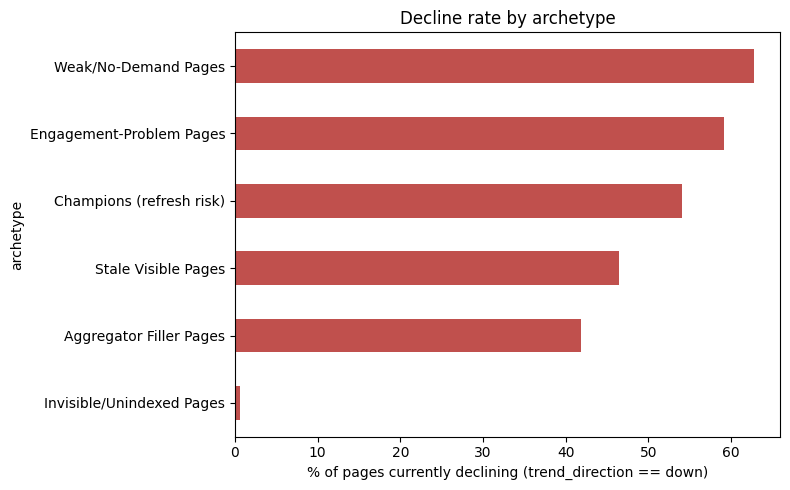

In [12]:
sizes = df['archetype'].value_counts()
plt.figure(figsize=(8,5))
sizes.plot(kind='barh', color='#3b6ea5')
plt.xlabel('Number of pages')
plt.title('Pages per archetype')
plt.tight_layout()
plt.savefig('figures/cluster_sizes.png', dpi=130)
plt.show()

decl = df.groupby('archetype')['trend_direction'].apply(lambda s: (s == 'down').mean() * 100).sort_values()
plt.figure(figsize=(8,5))
decl.plot(kind='barh', color='#c0504d')
plt.xlabel('% of pages currently declining (trend_direction == down)')
plt.title('Decline rate by archetype')
plt.tight_layout()
plt.savefig('figures/decline_by_archetype.png', dpi=130)
plt.show()

## 7. Limitations & honest framing

- **Clusters are a lens, not ground truth.** Silhouette scores of 0.16–0.20 mean these six groups sit on a continuum with soft boundaries, not six cleanly separated species of page. Stability checks (Section 3) show the *regions* are reproducible even though individual near-boundary pages could land in a neighboring cluster on a re-run.
- **This is metric clustering, not semantic clustering.** No article text is available in this release, so "archetype" here means "pages that behave alike on traffic/engagement/freshness metrics," never "pages that mean the same thing."
- **No causal claims.** A page sitting in "Stale Visible Pages" is *associated with* zero recent engagement, not *caused* to decline by its age — no experiment or causal design backs that stronger claim.
- **The starter slice is 30k pages from 32 clients**, not the full ~79M-row warehouse; archetype boundaries and the exact `k` could shift on the full release, and this analysis doesn't claim otherwise.
- **All findings use observed / directional / decision-support language** — the output is a ranked review queue for a human editor, not an automated trigger.

## 8. Reproducibility

- **Random seeds:** `42` throughout (StandardScaler is deterministic; KMeans and PCA seeded at 42; `n_init=10`).
- **Re-run from a fresh clone:**
  ```bash
  git clone https://github.com/muhammadfarhan2157-source/flyrank-ml-internship.git
  cd flyrank-ml-internship
  pip install -r requirements.txt
  jupyter nbconvert --to notebook --execute work/notebooks/capstone.ipynb
  ```
- **Inputs:** only `data/raw/content_refresh_anonymized.csv` (already committed, anonymized, ~30k rows).
- **Outputs committed as receipts:** `work/outputs/action_mapping.csv`, `work/outputs/cluster_profile.csv`, `work/notebooks/figures/*.png`.

---

## ML-12 — closing summary

**30-second question:** Out of thousands of content pages, which ones does a content team look at first, and what do they actually do to each one?

**1-minute method:** Standardize 16 safe, current-state metrics (traffic, CTR, engagement, freshness, content properties) per page from a 90-day window; cluster with KMeans (`k=6`, chosen by silhouette); profile each cluster on its raw numbers before naming it; check stability by re-seeding and bootstrapping before trusting the groups.

**One chart:** the PCA scatter (`figures/pca_clusters.png`) — six archetypes projected onto 2 components explaining ~33% of the original 16-feature variance (a projection for seeing the shape, not the clustering itself).

**One honest result:** the groups are moderately separated (silhouette ≈ 0.20) but highly reproducible (ARI mostly 0.80–1.00 across reseeding/bootstrapping) — real, useful groupings on a continuum, not six hard-edged categories.

**One recommendation:** route "Engagement-Problem Pages" (26% of inventory, high traffic, page-1 position, but 0.25% median CTR) to metadata/CTR review first — it's the largest pool of already-visible traffic being under-captured, ahead of "Stale Visible Pages" (rewrite candidates) and the prune/merge/monitor tail.

### Shareable cuts

**Social post:** Clustered 30k content pages on 16 safe performance metrics (no article text, no client-identifying data) into six archetypes — from "Champions" carrying the most traffic to "Invisible/Unindexed" pages sitting at zero. The honest finding: the groups are reproducible across re-seeding and bootstrapping (ARI ~0.8–1.0) even though they're not sharply separated (silhouette ~0.2) — real regions on a continuum, not hard categories. Turned it into a ranked action queue (protect / improve / rewrite / monitor / merge / prune) instead of a single opaque score.

**Employer-facing summary:** I built an unsupervised content-archetype clustering pipeline on FlyRank's anonymized search-performance dataset, turning 30,000 pages and 16 metrics into six actionable archetypes with a validated (stability-checked) clustering approach and a ranked action queue a content team could use immediately — while explicitly stating what the method can't claim (no semantic clustering, no causal decline claims).